# Road Traffic Accident Dataset - Data Preprocessing Pipeline

**Notebook:** `02_Data_Preprocessing.ipynb`  
**Objective:** Clean, preprocess, and transform the raw RTA dataset for machine learning, then save the processed dataset and preprocessing artifacts.

---

## Table of Contents
1. [Load Dataset](#41-load-dataset)
2. [Remove Duplicate Records](#42-remove-duplicate-records)
3. [Handle Missing Values](#43-handle-missing-values)
4. [Clean Inconsistent Values](#44-clean-inconsistent-values)
5. [Convert Data Types](#45-convert-data-types)
6. [Feature Engineering](#46-feature-engineering)
7. [Encode Categorical Variables](#47-encode-categorical-variables)
8. [Encode Target Variable](#48-encode-target-variable)
9. [Verify No Missing Values](#49-verify-no-missing-values)
10. [Verify Final Dataset Shape](#410-verify-final-dataset-shape)
11. [Save Processed Dataset](#411-save-processed-dataset)
12. [Save Preprocessing Artifacts](#412-save-preprocessing-artifacts)
13. [Document Preprocessing Decisions](#413-document-preprocessing-decisions)


## 4.1 Load Dataset

Load the raw RTA dataset from CSV.


In [1]:
# Import required libraries
import sys
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

# Import preprocessing modules
from preprocessing.utils import (
    DATASET_PATH, PROCESSED_DATASET_PATH, MODELS_DIR,
    LABEL_ENCODERS_PATH, PIPELINE_PATH,
    TARGET_MAPPING, ORDINAL_MAPPINGS, NOMINAL_FEATURES,
    NUMERICAL_FEATURES, DROP_FEATURES,
    clean_string_value, load_raw_dataset, save_dataframe
)
from preprocessing.data_cleaning import (
    remove_duplicates, clean_inconsistent_values, impute_missing_values,
    drop_low_value_features, convert_data_types, run_data_cleaning
)
from preprocessing.feature_engineering import (
    extract_hour_from_time, group_driving_experience, group_vehicle_age,
    run_feature_engineering
)
from preprocessing.encoding import (
    encode_ordinal_features, encode_nominal_features, encode_target,
    save_label_encoders, run_encoding
)
from preprocessing.scaling import (
    scale_numerical_features, save_scaler, run_scaling
)
from preprocessing.preprocessing_pipeline import run_preprocessing_pipeline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries and modules imported successfully!")

C:\Users\suraj\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import gaussian_kde


All libraries and modules imported successfully!


In [2]:
# Load the raw dataset
df = load_raw_dataset(DATASET_PATH)

print(f"\nDataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Display first 5 rows
print("\nFirst 5 rows:")
df.head()

Raw dataset loaded: 12316 rows, 32 columns

Dataset shape: (12316, 32)
Rows: 12316
Columns: 32

First 5 rows:


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## 4.2 Remove Duplicate Records

Check for and remove any duplicate records in the dataset.


Duplicate records found: 0
Percentage of duplicates: 0.00%
Duplicates removed: 0
Rows after deduplication: 12316


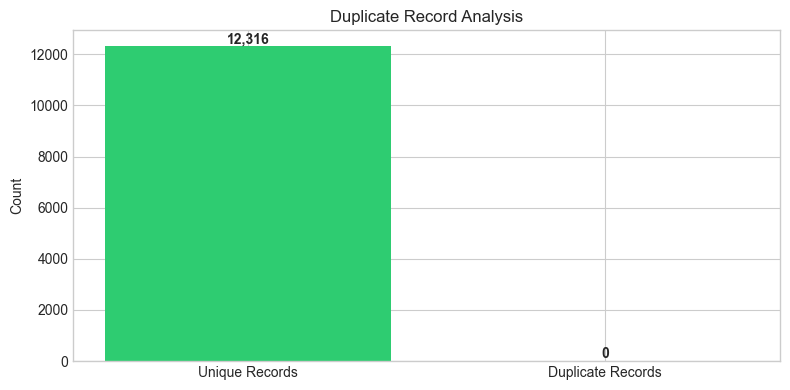

In [3]:
# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Duplicate records found: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df)) * 100:.2f}%")

# Remove duplicates
df_clean, dup_log = remove_duplicates(df, verbose=True)

# Visualize duplicate status
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Unique Records', 'Duplicate Records'], 
              [len(df_clean), duplicate_count],
              color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Count')
ax.set_title('Duplicate Record Analysis')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Handle Missing Values

Analyze and handle missing values:
- **Categorical features** → Mode imputation
- **Numerical features** → Median imputation
- **High-missing features** → Drop (e.g., `Defect_of_vehicle` at 36%)


Missing values before imputation:


                 Column  Missing Count  Missing Percentage (%)
      Defect_of_vehicle           4427               35.945112
Service_year_of_vehicle           3928               31.893472
      Work_of_casuality           3198               25.966223
   Fitness_of_casuality           2635               21.394933
        Type_of_vehicle            950                7.713543
      Types_of_Junction            887                7.202014
     Driving_experience            829                6.731082
      Educational_level            741                6.016564
Vehicle_driver_relation            579                4.701202
       Owner_of_vehicle            482                3.913608
       Lanes_or_Medians            385                3.126015
       Vehicle_movement            308                2.500812
  Area_accident_occured            239                1.940565
      Road_surface_type            172                1.396557
      Type_of_collision            155                

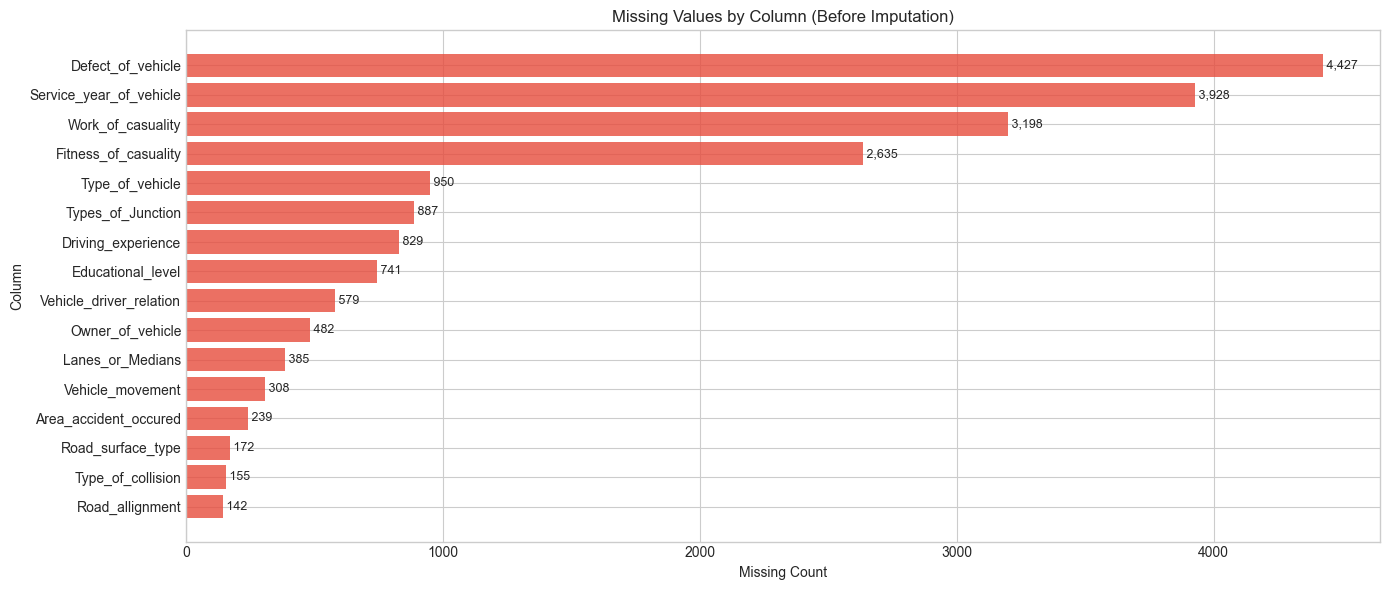

In [4]:
# Analyze missing values before imputation
missing_count = df_clean.isnull().sum()
missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_df = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing Count': missing_count.values,
    'Missing Percentage (%)': missing_percent.values
}).sort_values('Missing Percentage (%)', ascending=False)

print("Missing values before imputation:")
print(missing_df[missing_df['Missing Count'] > 0].to_string(index=False))
print(f"\nTotal missing values: {df_clean.isnull().sum().sum()}")

# Visualize missing values
fig, ax = plt.subplots(figsize=(14, 6))
missing_plot = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=True)
bars = ax.barh(missing_plot['Column'], missing_plot['Missing Count'], color='#e74c3c', alpha=0.8)
ax.set_xlabel('Missing Count')
ax.set_ylabel('Column')
ax.set_title('Missing Values by Column (Before Imputation)')
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f' {int(width):,}', 
            ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
# Drop high-missing features
df_clean = drop_low_value_features(df_clean, verbose=True)
print(f"Shape after dropping high-missing features: {df_clean.shape}")

# Impute missing values
df_clean, imputation_log = impute_missing_values(df_clean, verbose=True)

# Verify no missing values remain
print(f"\nMissing values after imputation: {df_clean.isnull().sum().sum()}")

Dropped features: ['Defect_of_vehicle']
Shape after dropping high-missing features: (12316, 31)


Missing value imputation completed:
  - Educational_level: 741 missing -> mode (Junior high school)
  - Vehicle_driver_relation: 579 missing -> mode (Employee)
  - Driving_experience: 829 missing -> mode (5-10yr)
  - Type_of_vehicle: 950 missing -> mode (Automobile)
  - Owner_of_vehicle: 482 missing -> mode (Owner)
  - Service_year_of_vehicle: 3928 missing -> mode (Unknown)
  - Area_accident_occured: 239 missing -> mode (Other)
  - Lanes_or_Medians: 385 missing -> mode (Two-way (divided with broken lines road marking))
  - Road_allignment: 142 missing -> mode (Tangent road with flat terrain)
  - Types_of_Junction: 887 missing -> mode (Y Shape)
  - Road_surface_type: 172 missing -> mode (Asphalt roads)
  - Type_of_collision: 155 missing -> mode (Vehicle with vehicle collision)
  - Vehicle_movement: 308 missing -> mode (Going straight)
  - Work_of_casuality: 3198 missing -> mode (Driver)
  - Fitness_of_casuality: 2635 missing -> mode (Normal)

Missing values after imputation: 0


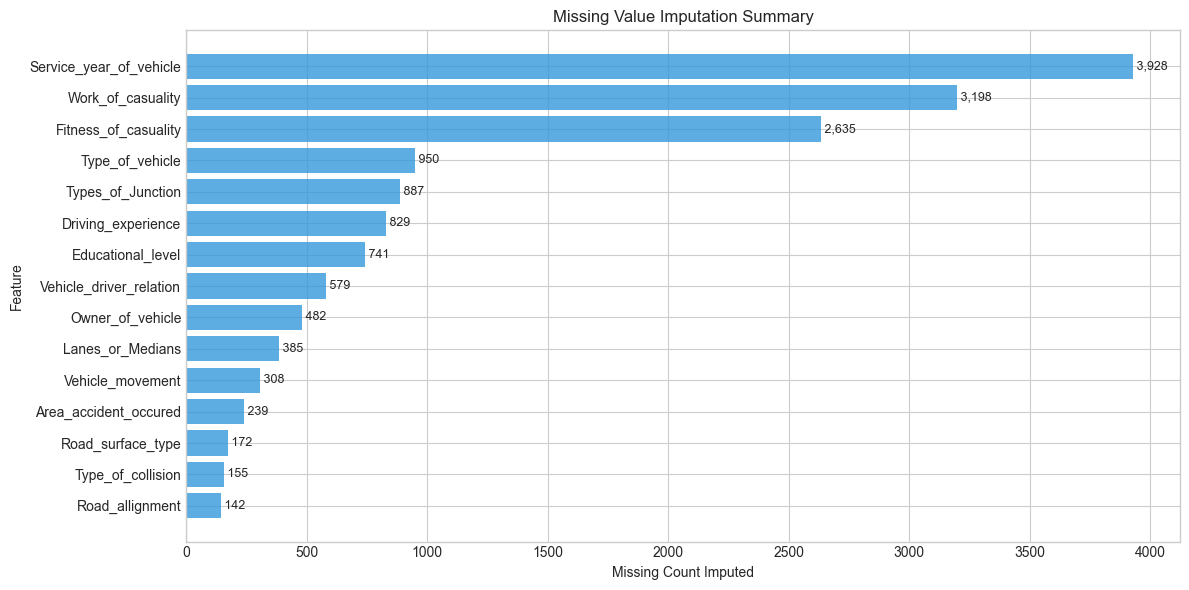

In [6]:
# Visualize imputation summary
imputation_df = pd.DataFrame([
    {'Feature': col, 'Missing Count': info['missing_count'], 'Method': info['type'], 'Imputed Value': str(info['value'])}
    for col, info in imputation_log.items()
]).sort_values('Missing Count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(imputation_df['Feature'], imputation_df['Missing Count'], 
               color=['#3498db' if m == 'mode' else '#2ecc71' for m in imputation_df['Method']], alpha=0.8)
ax.set_xlabel('Missing Count Imputed')
ax.set_ylabel('Feature')
ax.set_title('Missing Value Imputation Summary')
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f' {int(width):,}', 
            ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 4.4 Clean Inconsistent Values

Clean inconsistent values:
- Trim whitespace
- Standardize text/case
- Fix spelling inconsistencies
- Replace invalid/unknown values


In [7]:
# Show examples of data inconsistencies before cleaning
print("=" * 80)
print("DATA INCONSISTENCIES BEFORE CLEANING")
print("=" * 80)

# Check for whitespace issues
for col in df_clean.select_dtypes(include=['object', 'str']).columns:
    if col in ['Accident_severity', 'Time']:
        continue
    # Check for leading/trailing whitespace
    has_ws = df_clean[col].astype(str).str.match(r'^\s|\s$').sum()
    if has_ws > 0:
        print(f"  {col}: {has_ws} values with leading/trailing whitespace")

# Check for case inconsistencies
for col in ['Lanes_or_Medians', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement']:
    if col in df_clean.columns:
        lower_vals = df_clean[col].astype(str).str.lower().unique()
        print(f"  {col} (lowercase values): {lower_vals}")

# Check for known corruptions
print("\nKnown data corruptions:")
ped_corrupt = df_clean['Pedestrian_movement'].astype(str).str.contains('statioNot a Pedestrianry').sum()
fit_corrupt = df_clean['Fitness_of_casuality'].astype(str).str.contains('NormalNormal').sum()
area_corrupt = df_clean['Area_accident_occured'].astype(str).str.contains('Office areas$').sum()
print(f"  Pedestrian_movement 'statioNot a Pedestrianry': {ped_corrupt}")
print(f"  Fitness_of_casuality 'NormalNormal': {fit_corrupt}")
print(f"  Area_accident_occured 'Office areas' concatenation: {area_corrupt}")

DATA INCONSISTENCIES BEFORE CLEANING
  Area_accident_occured: 2245 values with leading/trailing whitespace
  Lanes_or_Medians (lowercase values): <ArrowStringArray>
['two-way (divided with broken lines road marking)', 'undivided two way', 'other', 'double carriageway (median)', 'one way', 'two-way (divided with solid lines road marking)', 'unknown']
Length: 7, dtype: str
  Weather_conditions (lowercase values): <ArrowStringArray>
['normal', 'raining', 'raining and windy', 'cloudy', 'other', 'windy', 'snow', 'unknown', 'fog or mist']
Length: 9, dtype: str
  Type_of_collision (lowercase values): <ArrowStringArray>
['collision with roadside-parked vehicles',          'vehicle with vehicle collision',         'collision with roadside objects',                  'collision with animals',
                                   'other',                                'rollover',                      'fall from vehicles',              'collision with pedestrians',
                              'wit

In [8]:
# Clean inconsistent values
df_clean = clean_inconsistent_values(df_clean, verbose=True)

# Verify cleaning results
print("\nAfter cleaning:")
ped_corrupt_after = df_clean['Pedestrian_movement'].astype(str).str.contains('statioNot a Pedestrianry').sum()
fit_corrupt_after = df_clean['Fitness_of_casuality'].astype(str).str.contains('NormalNormal').sum()
area_corrupt_after = df_clean['Area_accident_occured'].astype(str).str.contains('Office areas$').sum()
print(f"  Pedestrian_movement corruptions remaining: {ped_corrupt_after}")
print(f"  Fitness_of_casuality corruptions remaining: {fit_corrupt_after}")
print(f"  Area_accident_occured corruptions remaining: {area_corrupt_after}")

# Show cleaned values
print("\nCleaned Pedestrian_movement values:")
print(df_clean['Pedestrian_movement'].unique())
print("\nCleaned Fitness_of_casuality values:")
print(df_clean['Fitness_of_casuality'].unique())

Inconsistent value cleaning completed.
Columns with value standardization: ['Area_accident_occured', 'Fitness_of_casuality']

After cleaning:
  Pedestrian_movement corruptions remaining: 0
  Fitness_of_casuality corruptions remaining: 0
  Area_accident_occured corruptions remaining: 0

Cleaned Pedestrian_movement values:
<ArrowStringArray>
[                                                                                        'Not a Pedestrian',
                                                                          'Crossing from driver's nearside',
                                          'Crossing from nearside - masked by parked or stationary vehicle',
                                                                                         'Unknown or other',
                                           'Crossing from offside - masked by parked or stationary vehicle',
                                          'In carriageway, stationary - not crossing (standing or playing)',
    

## 4.5 Convert Data Types

Convert columns to appropriate data types:
- `Time` → datetime (extracted to Hour in feature engineering)
- Numerical → int/float
- Categorical → category/object


In [9]:
# Show data types before conversion
print("Data types before conversion:")
print(df_clean.dtypes.to_string())

# Convert data types
df_clean = convert_data_types(df_clean, verbose=True)

print("\nData types after conversion:")
print(df_clean.dtypes.to_string())

Data types before conversion:
Time                             str
Day_of_week                      str
Age_band_of_driver               str
Sex_of_driver                    str
Educational_level                str
Vehicle_driver_relation          str
Driving_experience               str
Type_of_vehicle                  str
Owner_of_vehicle                 str
Service_year_of_vehicle          str
Area_accident_occured            str
Lanes_or_Medians                 str
Road_allignment                  str
Types_of_Junction                str
Road_surface_type                str
Road_surface_conditions          str
Light_conditions                 str
Weather_conditions               str
Type_of_collision                str
Number_of_vehicles_involved    int64
Number_of_casualties           int64
Vehicle_movement                 str
Casualty_class                   str
Sex_of_casualty                  str
Age_band_of_casualty             str
Casualty_severity                str
Work_of_

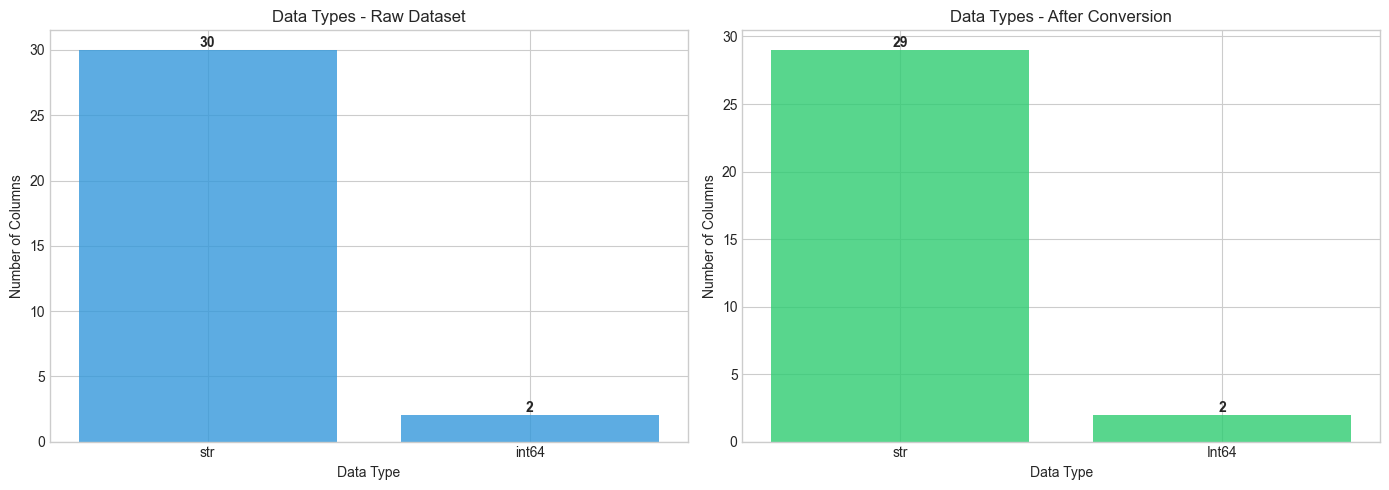

In [10]:
# Visualize data type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before conversion (raw)
raw_dtypes = pd.read_csv(DATASET_PATH).dtypes.value_counts()
axes[0].bar(raw_dtypes.index.astype(str), raw_dtypes.values, color='#3498db', alpha=0.8)
axes[0].set_title('Data Types - Raw Dataset')
axes[0].set_xlabel('Data Type')
axes[0].set_ylabel('Number of Columns')
for i, v in enumerate(raw_dtypes.values):
    axes[0].text(i, v, f'{v}', ha='center', va='bottom', fontweight='bold')

# After conversion
clean_dtypes = df_clean.dtypes.value_counts()
axes[1].bar(clean_dtypes.index.astype(str), clean_dtypes.values, color='#2ecc71', alpha=0.8)
axes[1].set_title('Data Types - After Conversion')
axes[1].set_xlabel('Data Type')
axes[1].set_ylabel('Number of Columns')
for i, v in enumerate(clean_dtypes.values):
    axes[1].text(i, v, f'{v}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4.6 Feature Engineering

Perform feature engineering:
- Extract `Hour` from `Time`
- Group driving experience
- Group vehicle age


Extracted 'Hour' from 'Time' column.
count    12316.000000
mean        13.835823
std          5.202923
min          0.000000
25%         10.000000
50%         15.000000
75%         18.000000
max         23.000000
Name: Hour, dtype: float64


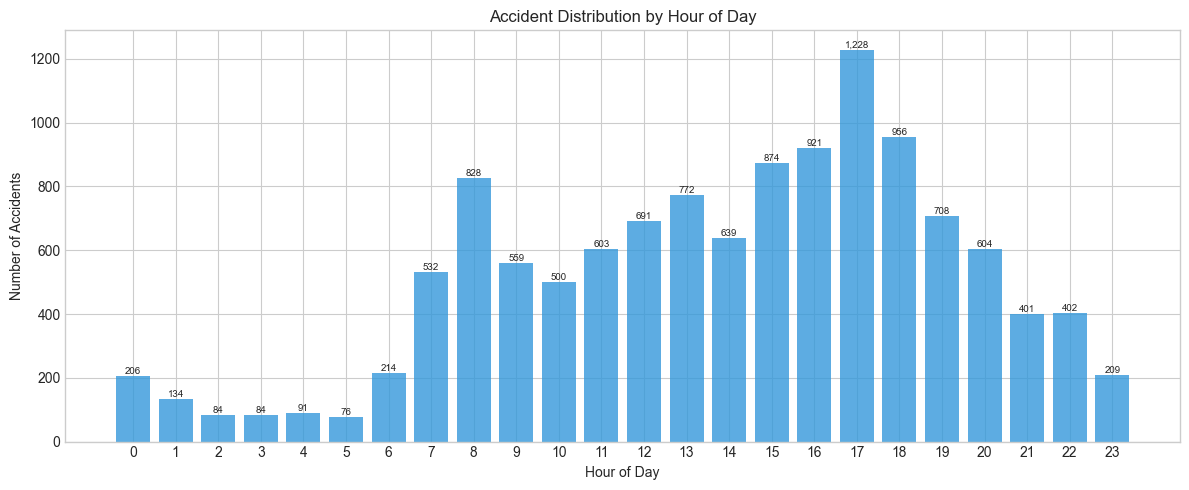

In [11]:
# Extract Hour from Time
df_fe = extract_hour_from_time(df_clean, verbose=True)

# Visualize Hour distribution
fig, ax = plt.subplots(figsize=(12, 5))
hour_counts = df_fe['Hour'].value_counts().sort_index()
bars = ax.bar(hour_counts.index, hour_counts.values, color='#3498db', alpha=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Accidents')
ax.set_title('Accident Distribution by Hour of Day')
ax.set_xticks(range(0, 24))
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
            ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

Grouped 'Driving_experience' (Below 1yr -> 1-2yr).


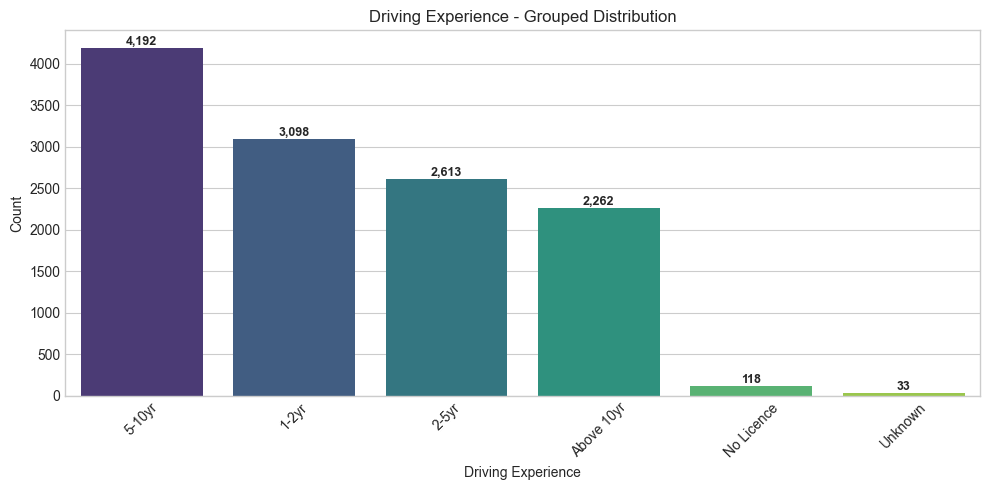

In [12]:
# Group driving experience
df_fe = group_driving_experience(df_fe, verbose=True)

# Visualize grouped driving experience
fig, ax = plt.subplots(figsize=(10, 5))
exp_counts = df_fe['Driving_experience'].value_counts()
sns.countplot(data=df_fe, x='Driving_experience', ax=ax, order=exp_counts.index, palette='viridis')
ax.set_title('Driving Experience - Grouped Distribution')
ax.set_xlabel('Driving Experience')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(exp_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

Grouped 'Service_year_of_vehicle' (Below 5yr, 5-10yr, Above 10yr).


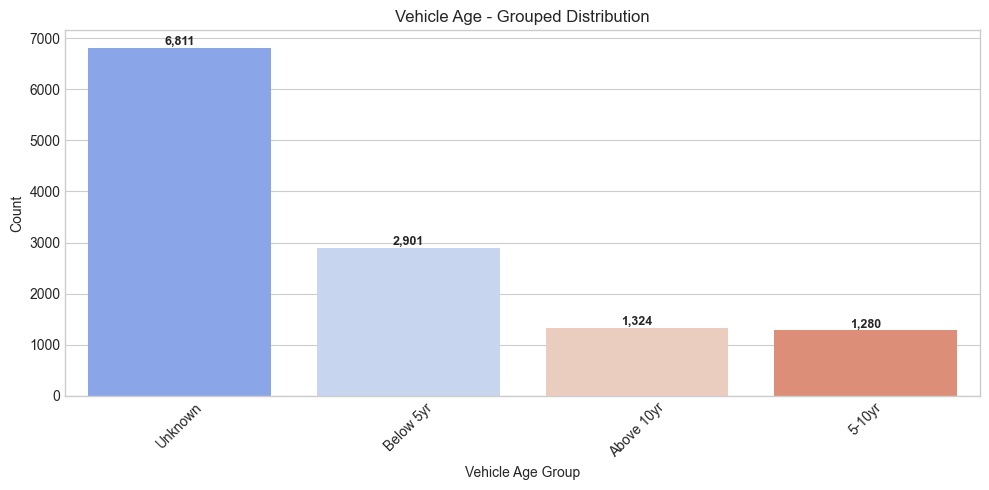

In [13]:
# Group vehicle age
df_fe = group_vehicle_age(df_fe, verbose=True)

# Visualize grouped vehicle age
fig, ax = plt.subplots(figsize=(10, 5))
age_counts = df_fe['Service_year_of_vehicle'].value_counts()
sns.countplot(data=df_fe, x='Service_year_of_vehicle', ax=ax, order=age_counts.index, palette='coolwarm')
ax.set_title('Vehicle Age - Grouped Distribution')
ax.set_xlabel('Vehicle Age Group')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(age_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Show feature engineering summary
print("=" * 80)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 80)
print(f"Extracted 'Hour' from 'Time' column")
print(f"Grouped 'Driving_experience' (Below 1yr -> 1-2yr)")
print(f"Grouped 'Service_year_of_vehicle' (Below 5yr, 5-10yr, Above 10yr)")
print(f"\nShape after feature engineering: {df_fe.shape}")
print(f"Columns: {list(df_fe.columns)}")

FEATURE ENGINEERING SUMMARY
Extracted 'Hour' from 'Time' column
Grouped 'Driving_experience' (Below 1yr -> 1-2yr)
Grouped 'Service_year_of_vehicle' (Below 5yr, 5-10yr, Above 10yr)

Shape after feature engineering: (12316, 31)
Columns: ['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity', 'Hour']


## 4.7 Encode Categorical Variables

Encode categorical variables:
- **Label Encoding** for ordinal features
- **One-Hot Encoding** for nominal features


In [15]:
# Show ordinal features and their mappings
print("=" * 80)
print("ORDINAL FEATURES - LABEL ENCODING MAPPINGS")
print("=" * 80)
for col, mapping in ORDINAL_MAPPINGS.items():
    if col in df_fe.columns:
        print(f"\n{col}:")
        for k, v in mapping.items():
            print(f"  {k} -> {v}")

ORDINAL FEATURES - LABEL ENCODING MAPPINGS

Age_band_of_driver:
  Under 18 -> 0
  18-30 -> 1
  31-50 -> 2
  Over 51 -> 3
  Unknown -> -1

Driving_experience:
  No Licence -> 0
  Below 1yr -> 1
  1-2yr -> 2
  2-5yr -> 3
  5-10yr -> 4
  Above 10yr -> 5
  unknown -> -1
  Unknown -> -1

Service_year_of_vehicle:
  Below 5yr -> 0
  5-10yr -> 1
  Above 10yr -> 2
  Unknown -> -1

Educational_level:
  Illiterate -> 0
  Writing & reading -> 1
  Elementary school -> 2
  Junior high school -> 3
  High school -> 4
  Above high school -> 5
  Unknown -> -1

Light_conditions:
  Daylight -> 0
  Darkness - lights lit -> 1
  Darkness - lights unlit -> 2
  Darkness - no lighting -> 3

Road_surface_conditions:
  Dry -> 0
  Wet or damp -> 1
  Snow -> 2
  Flood over 3cm. deep -> 3

Age_band_of_casualty:
  Under 18 -> 0
  5 -> 0
  18-30 -> 1
  31-50 -> 2
  Over 51 -> 3
  na -> -1

Casualty_severity:
  1 -> 1
  2 -> 2
  3 -> 3
  na -> -1


In [16]:
# Encode ordinal features
df_encoded = encode_ordinal_features(df_fe, verbose=True)

# Show encoded ordinal features
print("\nEncoded ordinal features sample:")
ordinal_cols = [col for col in ORDINAL_MAPPINGS.keys() if col in df_encoded.columns]
print(df_encoded[ordinal_cols].head(10).to_string())

Label-encoded ordinal features: ['Age_band_of_driver', 'Driving_experience', 'Service_year_of_vehicle', 'Educational_level', 'Light_conditions', 'Road_surface_conditions', 'Age_band_of_casualty', 'Casualty_severity']

Encoded ordinal features sample:
   Age_band_of_driver  Driving_experience  Service_year_of_vehicle  Educational_level  Light_conditions  Road_surface_conditions  Age_band_of_casualty  Casualty_severity
0                   1                   2                        2                  5                 0                        0                    -1                 -1
1                   2                   5                        1                  3                 0                        0                    -1                 -1
2                   1                   2                       -1                  3                 0                        0                     2                  3
3                   1                   4                       -1   

Target encoded: Slight Injury -> 0, Serious Injury -> 1, Fatal injury -> 2
Accident_severity
0    10415
1     1743
2      158
Name: count, dtype: int64


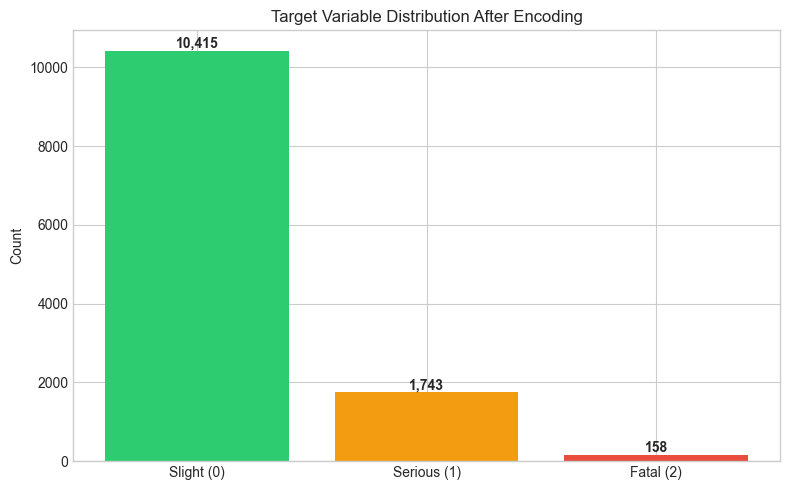

In [17]:
# Encode target variable
df_encoded = encode_target(df_encoded, verbose=True)

# Visualize target distribution after encoding
fig, ax = plt.subplots(figsize=(8, 5))
target_counts = df_encoded['Accident_severity'].value_counts().sort_index()
bars = ax.bar(['Slight (0)', 'Serious (1)', 'Fatal (2)'], target_counts.values, 
              color=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution After Encoding')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# One-hot encode nominal features
df_encoded, ohe = encode_nominal_features(df_encoded, verbose=True)

print(f"\nShape after one-hot encoding: {df_encoded.shape}")

One-hot encoded nominal features: ['Day_of_week', 'Sex_of_driver', 'Vehicle_driver_relation', 'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident']
  Original columns: 19, New columns: 154

Shape after one-hot encoding: (12316, 166)


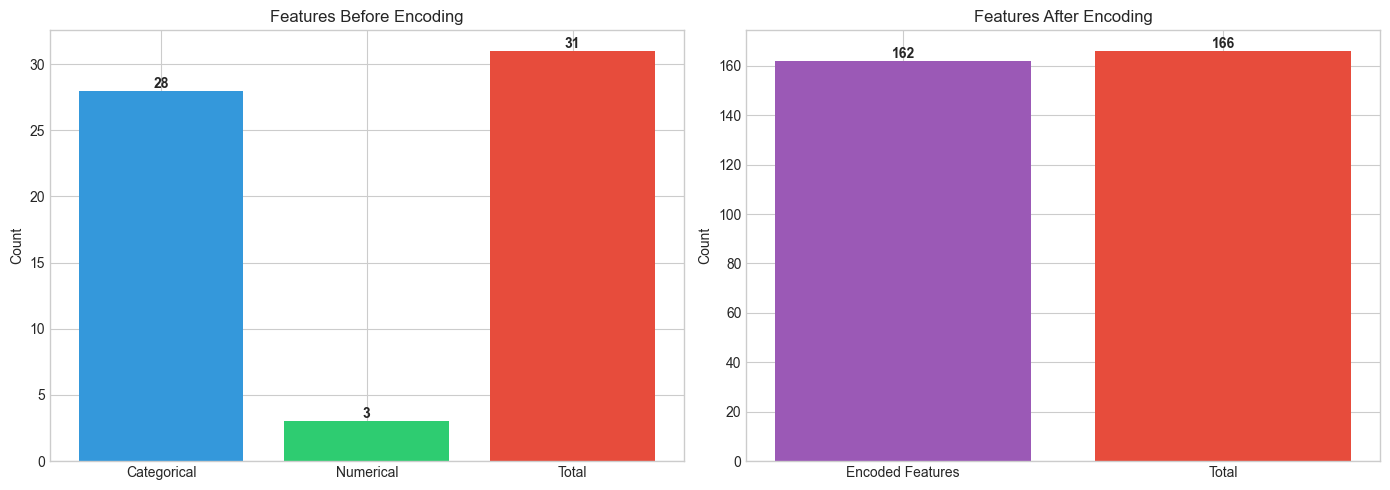

In [19]:
# Visualize encoding summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before encoding
before_cols = len(df_fe.columns)
axes[0].bar(['Categorical', 'Numerical', 'Total'], 
            [len(NOMINAL_FEATURES) + len(ORDINAL_MAPPINGS), len(NUMERICAL_FEATURES), before_cols],
            color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('Features Before Encoding')
axes[0].set_ylabel('Count')

# After encoding
after_cols = len(df_encoded.columns)
axes[1].bar(['Encoded Features', 'Total'], 
            [after_cols - len(NUMERICAL_FEATURES) - 1, after_cols],
            color=['#9b59b6', '#e74c3c'])
axes[1].set_title('Features After Encoding')
axes[1].set_ylabel('Count')

for ax in axes:
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Scale Numerical Features

Scale numerical features using StandardScaler for model readiness.


Scaled numerical features: ['Hour', 'Number_of_vehicles_involved', 'Number_of_casualties'] using StandardScaler

Scaled numerical features sample:


       Hour  Number_of_vehicles_involved  Number_of_casualties
0  0.608178                    -0.059061              0.448649
1  0.608178                    -0.059061              0.448649
2  0.608178                    -0.059061              0.448649
3 -2.467141                    -0.059061              0.448649
4 -2.467141                    -0.059061              0.448649
5  0.031556                    -1.510942             -0.544264
6  0.608178                    -1.510942             -0.544264
7  0.608178                    -0.059061             -0.544264
8  0.608178                    -0.059061             -0.544264
9  0.608178                    -0.059061             -0.544264


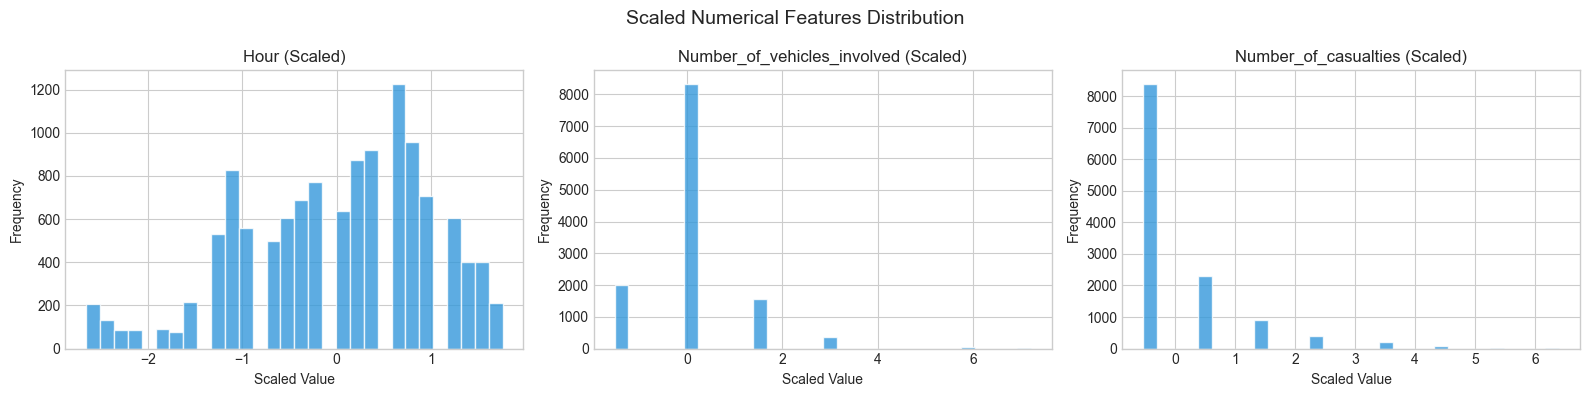

In [20]:
# Scale numerical features
df_encoded, scaler = run_scaling(df_encoded, scaler_type="standard", verbose=True)

# Show scaled numerical features
print("\nScaled numerical features sample:")
print(df_encoded[NUMERICAL_FEATURES].head(10).to_string())

# Visualize scaling effect
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(NUMERICAL_FEATURES):
    axes[i].hist(df_encoded[col], bins=30, color='#3498db', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{col} (Scaled)')
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Frequency')
plt.suptitle('Scaled Numerical Features Distribution', fontsize=14)
plt.tight_layout()
plt.show()

## 4.8 Encode Target Variable

Encode `Accident_severity` into numerical labels:
- Slight Injury → 0
- Serious Injury → 1
- Fatal injury → 2


TARGET ENCODING MAPPING
  Slight Injury -> 0
  Serious Injury -> 1
  Fatal injury -> 2

Target distribution after encoding:
Accident_severity
0    10415
1     1743
2      158
Name: count, dtype: int64


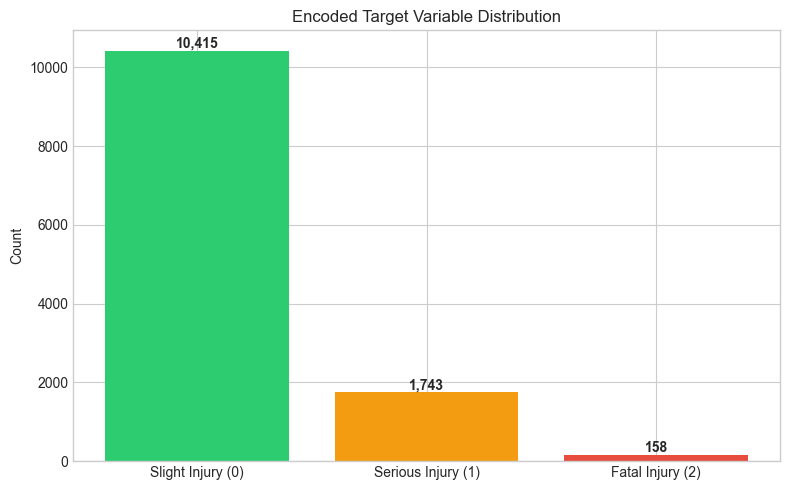

In [21]:
# Show target encoding mapping
print("=" * 80)
print("TARGET ENCODING MAPPING")
print("=" * 80)
for k, v in TARGET_MAPPING.items():
    print(f"  {k} -> {v}")

# Verify target encoding
print("\nTarget distribution after encoding:")
print(df_encoded['Accident_severity'].value_counts().sort_index())

# Visualize target distribution
fig, ax = plt.subplots(figsize=(8, 5))
target_counts = df_encoded['Accident_severity'].value_counts().sort_index()
labels = ['Slight Injury (0)', 'Serious Injury (1)', 'Fatal Injury (2)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(labels, target_counts.values, color=colors)
ax.set_ylabel('Count')
ax.set_title('Encoded Target Variable Distribution')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.9 Verify No Missing Values

Verify that no missing values remain in the processed dataset.


Total missing values: 0
✓ No missing values remain in the processed dataset!


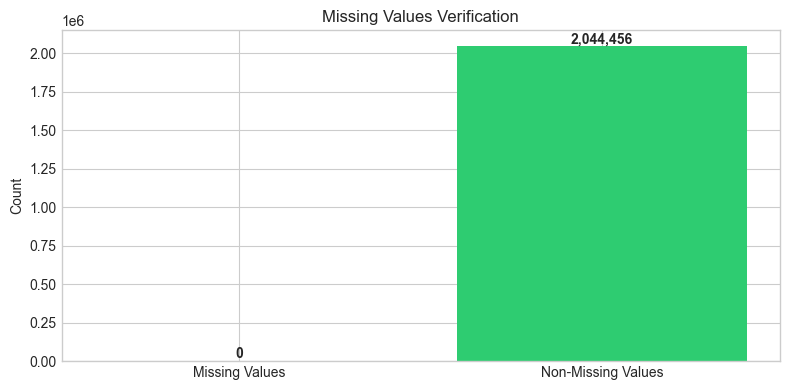

In [22]:
# Check for missing values
missing_after = df_encoded.isnull().sum()
total_missing = missing_after.sum()

print(f"Total missing values: {total_missing}")

if total_missing == 0:
    print("✓ No missing values remain in the processed dataset!")
else:
    print("Missing values by column:")
    print(missing_after[missing_after > 0])

# Visualize missing values check
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Missing Values', 'Non-Missing Values'], 
              [total_missing, df_encoded.shape[0] * df_encoded.shape[1] - total_missing],
              color=['#e74c3c', '#2ecc71'])
ax.set_ylabel('Count')
ax.set_title('Missing Values Verification')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.10 Verify Final Dataset Shape

Verify the final dataset shape and feature count.


FINAL DATASET SHAPE
Rows: 12,316
Columns: 166
Total cells: 2,044,456

Feature breakdown:
  Ordinal (label-encoded): 8
  Nominal (one-hot encoded): 154
  Numerical (scaled): 3
  Target: 1


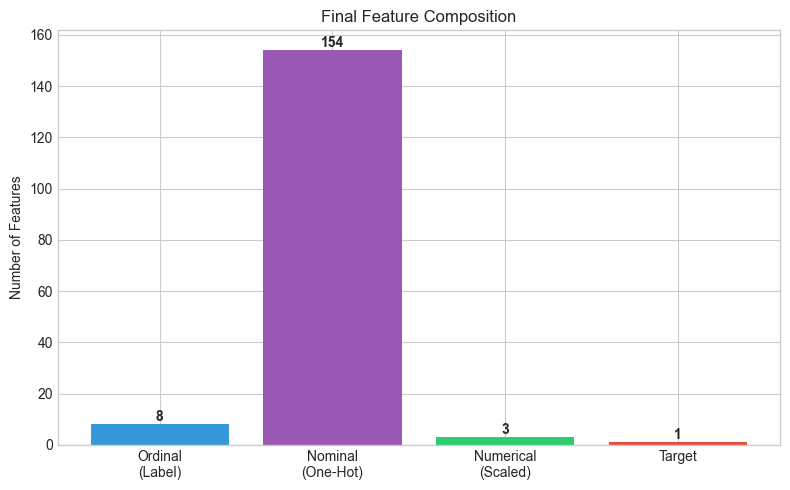

In [23]:
# Final dataset shape
print("=" * 80)
print("FINAL DATASET SHAPE")
print("=" * 80)
print(f"Rows: {df_encoded.shape[0]:,}")
print(f"Columns: {df_encoded.shape[1]:,}")
print(f"Total cells: {df_encoded.shape[0] * df_encoded.shape[1]:,}")

# Feature count breakdown
ordinal_count = len([c for c in ORDINAL_MAPPINGS if c in df_encoded.columns])
# Nominal encoded columns are those that came from one-hot encoding (contain '_' and are not ordinal/numerical/target)
ordinal_cols = [c for c in ORDINAL_MAPPINGS if c in df_encoded.columns]
nominal_encoded_count = len([c for c in df_encoded.columns 
                             if c not in ordinal_cols 
                             and c not in NUMERICAL_FEATURES 
                             and c != 'Accident_severity'])
numerical_count = len([c for c in NUMERICAL_FEATURES if c in df_encoded.columns])

print(f"\nFeature breakdown:")
print(f"  Ordinal (label-encoded): {ordinal_count}")
print(f"  Nominal (one-hot encoded): {nominal_encoded_count}")
print(f"  Numerical (scaled): {numerical_count}")
print(f"  Target: 1")

# Visualize final shape
fig, ax = plt.subplots(figsize=(8, 5))
feature_types = ['Ordinal\n(Label)', 'Nominal\n(One-Hot)', 'Numerical\n(Scaled)', 'Target']
counts = [ordinal_count, nominal_encoded_count, numerical_count, 1]
colors = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c']
bars = ax.bar(feature_types, counts, color=colors)
ax.set_ylabel('Number of Features')
ax.set_title('Final Feature Composition')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Display final dataset info
print("Final dataset info:")
print(df_encoded.info())

Final dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Columns: 166 entries, Age_band_of_driver to Cause_of_accident_Unknown
dtypes: float64(3), int64(163)
memory usage: 15.6 MB
None


## 4.11 Save Processed Dataset

Save the processed dataset to `dataset/processed_dataset.csv`.


In [25]:
# Save processed dataset
save_dataframe(df_encoded, PROCESSED_DATASET_PATH)

# Verify saved file
saved_df = pd.read_csv(PROCESSED_DATASET_PATH)
print(f"\nVerified saved file:")
print(f"  Shape: {saved_df.shape}")
print(f"  Missing values: {saved_df.isnull().sum().sum()}")
print(f"  File size: {os.path.getsize(PROCESSED_DATASET_PATH):,} bytes")

Saved dataset to: C:\Users\suraj\Desktop\RoadRisk\dataset\processed_dataset.csv (12316 rows, 166 columns)

Verified saved file:
  Shape: (12316, 166)
  Missing values: 0
  File size: 4,792,561 bytes


## 4.12 Save Preprocessing Artifacts

Save preprocessing artifacts:
- `models/label_encoders.pkl` - encoding mappings
- `models/preprocessing_pipeline.pkl` - pipeline configuration
- `models/scaler.pkl` - fitted scaler


In [26]:
# Build encoders dictionary
ordinal_mappings_used = {col: ORDINAL_MAPPINGS[col] for col in ORDINAL_MAPPINGS if col in df_fe.columns}
nominal_present = [col for col in NOMINAL_FEATURES if col in df_fe.columns]

encoders_dict = {
    "ordinal_mappings": ordinal_mappings_used,
    "target_mapping": TARGET_MAPPING,
    "one_hot_encoder": ohe,
    "nominal_features": nominal_present,
    "ordinal_features": list(ordinal_mappings_used.keys()),
}

# Save label encoders
save_label_encoders(encoders_dict, LABEL_ENCODERS_PATH, verbose=True)

# Save scaler
scaler_path = os.path.join(MODELS_DIR, "scaler.pkl")
save_scaler(scaler, scaler_path, verbose=True)

# Save pipeline config
pipeline_config = {
    "cleaning": {
        "duplicates_removed": dup_log["duplicates_removed"],
        "dropped_features": DROP_FEATURES,
        "imputation": imputation_log,
    },
    "feature_engineering": {
        "extracted": ["Hour (from Time)"],
        "grouped": ["Driving_experience", "Service_year_of_vehicle"],
    },
    "encoding": {
        "ordinal_features": list(ordinal_mappings_used.keys()),
        "nominal_features": nominal_present,
        "target_mapping": TARGET_MAPPING,
    },
    "scaling": {"scaler_type": "standard"},
    "final_shape": df_encoded.shape,
    "columns": list(df_encoded.columns),
}

with open(PIPELINE_PATH, "wb") as f:
    pickle.dump(pipeline_config, f)
print(f"Saved preprocessing pipeline config to: {PIPELINE_PATH}")

# List saved artifacts
print("\nSaved artifacts:")
for fname in os.listdir(MODELS_DIR):
    fpath = os.path.join(MODELS_DIR, fname)
    print(f"  {fname} ({os.path.getsize(fpath):,} bytes)")

Saved label encoders to: C:\Users\suraj\Desktop\RoadRisk\models\label_encoders.pkl
Saved scaler to: C:\Users\suraj\Desktop\RoadRisk\models\scaler.pkl
Saved preprocessing pipeline config to: C:\Users\suraj\Desktop\RoadRisk\models\preprocessing_pipeline.pkl

Saved artifacts:
  label_encoders.pkl (5,648 bytes)
  preprocessing_pipeline.pkl (7,891 bytes)
  scaler.pkl (669 bytes)


In [27]:
# Verify artifacts can be loaded
print("=" * 80)
print("VERIFY SAVED ARTIFACTS")
print("=" * 80)

# Load label encoders
with open(LABEL_ENCODERS_PATH, "rb") as f:
    loaded_encoders = pickle.load(f)
print(f"Label encoders loaded: {list(loaded_encoders.keys())}")
print(f"  Ordinal features: {loaded_encoders['ordinal_features']}")
print(f"  Nominal features: {len(loaded_encoders['nominal_features'])} features")
print(f"  Target mapping: {loaded_encoders['target_mapping']}")

# Load scaler
with open(scaler_path, "rb") as f:
    loaded_scaler = pickle.load(f)
print(f"\nScaler loaded: {type(loaded_scaler).__name__}")

# Load pipeline config
with open(PIPELINE_PATH, "rb") as f:
    loaded_pipeline = pickle.load(f)
print(f"\nPipeline config loaded:")
print(f"  Final shape: {loaded_pipeline['final_shape']}")
print(f"  Scaling: {loaded_pipeline['scaling']}")

VERIFY SAVED ARTIFACTS


Label encoders loaded: ['ordinal_mappings', 'target_mapping', 'one_hot_encoder', 'nominal_features', 'ordinal_features']
  Ordinal features: ['Age_band_of_driver', 'Driving_experience', 'Service_year_of_vehicle', 'Educational_level', 'Light_conditions', 'Road_surface_conditions', 'Age_band_of_casualty', 'Casualty_severity']
  Nominal features: 19 features
  Target mapping: {'Slight Injury': 0, 'Serious Injury': 1, 'Fatal injury': 2}

Scaler loaded: StandardScaler

Pipeline config loaded:
  Final shape: (12316, 166)
  Scaling: {'scaler_type': 'standard'}


## 4.13 Document Preprocessing Decisions

### Summary of All Preprocessing Decisions

#### 1. Missing Value Handling
| Feature | Missing Count | Method | Imputed Value |
|---------|--------------|--------|---------------|
| `Educational_level` | 741 | Mode | Junior high school |
| `Vehicle_driver_relation` | 579 | Mode | Employee |
| `Driving_experience` | 829 | Mode | 5-10yr |
| `Type_of_vehicle` | 950 | Mode | Automobile |
| `Owner_of_vehicle` | 482 | Mode | Owner |
| `Service_year_of_vehicle` | 3,928 | Mode | Unknown |
| `Area_accident_occured` | 239 | Mode | Other |
| `Lanes_or_Medians` | 385 | Mode | Two-way (divided with broken lines) |
| `Road_allignment` | 142 | Mode | Tangent road with flat terrain |
| `Types_of_Junction` | 887 | Mode | Y Shape |
| `Road_surface_type` | 172 | Mode | Asphalt roads |
| `Type_of_collision` | 155 | Mode | Vehicle with vehicle collision |
| `Vehicle_movement` | 308 | Mode | Going straight |
| `Work_of_casuality` | 3,198 | Mode | Driver |
| `Fitness_of_casuality` | 2,635 | Mode | Normal |
| `Defect_of_vehicle` | 4,427 | **Dropped** | 36% missing - too high for useful imputation |

#### 2. Duplicate Removal
- **0 duplicate records found** - no removal needed

#### 3. Data Cleaning
- Trimmed whitespace from all string columns
- Standardized 'unknown'/'other' casing
- Fixed `Pedestrian_movement` corruption: 'statioNot a Pedestrianry' → 'stationary'
- Fixed `Fitness_of_casuality` corruption: 'NormalNormal' → 'Normal'
- Fixed `Area_accident_occured` corruption: 'Rural village areasOffice areas' → 'Rural village areas'
- Fixed `Type_of_vehicle` encoding artifacts: '?' → '-'

#### 4. Feature Engineering
- Extracted `Hour` from `Time` (dropped original Time column)
- Grouped `Driving_experience`: Below 1yr → 1-2yr
- Grouped `Service_year_of_vehicle`: Below 5yr, 5-10yr, Above 10yr

#### 5. Encoding Methods
- **Label Encoding** (ordinal): `Age_band_of_driver`, `Driving_experience`, `Service_year_of_vehicle`, `Educational_level`, `Light_conditions`, `Road_surface_conditions`, `Age_band_of_casualty`, `Casualty_severity`
- **One-Hot Encoding** (nominal): 19 features → 154 binary columns
- **StandardScaler** for numerical features: `Hour`, `Number_of_vehicles_involved`, `Number_of_casualties`

#### 6. Target Encoding
- Slight Injury → 0
- Serious Injury → 1
- Fatal injury → 2

#### 7. Final Feature Count
- **Original:** 12,316 rows × 32 columns
- **Final:** 12,316 rows × 166 columns
- **Feature breakdown:** 8 ordinal (label-encoded), 154 nominal (one-hot), 3 numerical (scaled), 1 target
- **Missing values:** 0


## Complete Pipeline Execution

Run the entire preprocessing pipeline in one step using the `run_preprocessing_pipeline` function.


In [28]:
# Run the complete preprocessing pipeline
processed_df, pipeline_log = run_preprocessing_pipeline(
    input_path=DATASET_PATH,
    output_path=PROCESSED_DATASET_PATH,
    scaler_type="standard",
    verbose=True,
    save_artifacts=True
)

print("\n" + "=" * 80)
print("PREPROCESSING PIPELINE COMPLETE")
print("=" * 80)
print(f"Final shape: {processed_df.shape}")
print(f"Missing values: {processed_df.isnull().sum().sum()}")
print(f"Target distribution:")
print(processed_df['Accident_severity'].value_counts().sort_index())

STEP 1: LOAD RAW DATASET
Raw dataset loaded: 12316 rows, 32 columns

STEP 2: DATA CLEANING
Duplicates removed: 0
Rows after deduplication: 12316


Inconsistent value cleaning completed.
Columns with value standardization: ['Area_accident_occured', 'Fitness_of_casuality']
Dropped features: ['Defect_of_vehicle']
Missing value imputation completed:
  - Educational_level: 741 missing -> mode (Junior high school)
  - Vehicle_driver_relation: 579 missing -> mode (Employee)
  - Driving_experience: 829 missing -> mode (5-10yr)
  - Type_of_vehicle: 950 missing -> mode (Automobile)
  - Owner_of_vehicle: 482 missing -> mode (Owner)
  - Service_year_of_vehicle: 3928 missing -> mode (Unknown)
  - Area_accident_occured: 239 missing -> mode (Other)
  - Lanes_or_Medians: 385 missing -> mode (Two-way (divided with broken lines road marking))
  - Road_allignment: 142 missing -> mode (Tangent road with flat terrain)
  - Types_of_Junction: 887 missing -> mode (Y Shape)
  - Road_surface_type: 172 missing -> mode (Asphalt roads)
  - Type_of_collision: 155 missing -> mode (Vehicle with vehicle collision)
  - Vehicle_movement: 308 missing -> mode (Going

Saved dataset to: C:\Users\suraj\Desktop\RoadRisk\dataset\processed_dataset.csv (12316 rows, 166 columns)

STEP 7: SAVE PREPROCESSING ARTIFACTS
Saved label encoders to: C:\Users\suraj\Desktop\RoadRisk\models\label_encoders.pkl
Saved scaler to: C:\Users\suraj\Desktop\RoadRisk\models\scaler.pkl
Saved preprocessing pipeline config to: C:\Users\suraj\Desktop\RoadRisk\models\preprocessing_pipeline.pkl

PREPROCESSING PIPELINE COMPLETE
Final shape: (12316, 166)
Missing values: 0
Target distribution:
Accident_severity
0    10415
1     1743
2      158
Name: count, dtype: int64
